# Chess Elo stacking from CSV - 1000x100

This notebook improves the base player-level CSV by stacking three complementary models:
- `CatBoost`
- `XGBoost (tuned)`
- `Ridge`

The key idea is to train a meta-model on out-of-fold predictions from the train split only, then evaluate on the held-out test split.
This avoids tuning the blend directly on the test set.


In [15]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression, HuberRegressor, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
from catboost import CatBoostRegressor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.3f}'.format)
RANDOM_STATE = 42


In [16]:
IN_COLAB = Path('/content').exists()
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

candidates = [
    Path('data/processed/player_level_features_v4_1000x100.csv'),
    Path('/content/drive/MyDrive/projetMind/data/processed/player_level_features_v4_1000x100.csv'),
    Path('/content/drive/MyDrive/projetMind/data/processed/player_level_features_v4_1000x100.csv'),
]

def pick_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

PLAYER_CSV = pick_first_existing(candidates)
print('PLAYER_CSV =', PLAYER_CSV)
if PLAYER_CSV is None:
    raise FileNotFoundError('player_level_features_v4_1000x100.csv introuvable')


PLAYER_CSV = player_level_features_v4_1000x100.csv


In [17]:
player_df = pd.read_csv(PLAYER_CSV)
print('player_df shape:', player_df.shape)
player_df.head(2)


player_df shape: (1000, 148)


,target_name,loss_mean_mean,loss_mean_std,loss_median_mean,loss_median_std,loss_std_mean,loss_std_std,loss_p90_mean,loss_p90_std,loss_max_mean,loss_max_std,loss_log_mean_mean,loss_log_mean_std,rate_good_mean,rate_good_std,rate_inaccuracy_mean,rate_inaccuracy_std,rate_mistake_mean,rate_mistake_std,rate_blunder_mean,rate_blunder_std,rate_error_mean,rate_error_std,n_blunders_mean,n_blunders_std,n_mistakes_mean,n_mistakes_std,rate_loss_gt100_mean,rate_loss_gt100_std,rate_loss_gt200_mean,rate_loss_gt200_std,loss_opening_mean_mean,loss_opening_mean_std,loss_middlegame_mean_mean,loss_middlegame_mean_std,loss_endgame_mean_mean,loss_endgame_mean_std,loss_opening_std_mean,loss_opening_std_std,loss_middlegame_std_mean,loss_middlegame_std_std,loss_endgame_std_mean,loss_endgame_std_std,time_mean_s_mean,time_mean_s_std,time_median_s_mean,time_median_s_std,time_std_s_mean,time_std_s_std,time_log_mean_mean,time_log_mean_std,clock_mean_s_mean,clock_mean_s_std,time_mean_on_error_mean,time_mean_on_error_std,time_mean_on_blunder_mean,time_mean_on_blunder_std,time_opening_mean_s_mean,time_opening_mean_s_std,time_middlegame_mean_s_mean,time_middlegame_mean_s_std,time_endgame_mean_s_mean,time_endgame_mean_s_std,error_low_time_rate_mean,error_low_time_rate_std,blunder_low_time_rate_mean,blunder_low_time_rate_std,good_fast_move_rate_mean,good_fast_move_rate_std,avg_time_on_critical_moves_mean,avg_time_on_critical_moves_std,time_used_when_equal_mean,time_used_when_equal_std,time_used_before_blunder_mean,time_used_before_blunder_std,time_pressure_by_phase_opening_mean,time_pressure_by_phase_opening_std,time_pressure_by_phase_middlegame_mean,time_pressure_by_phase_middlegame_std,time_pressure_by_phase_endgame_mean,time_pressure_by_phase_endgame_std,loss_when_winning_mean,loss_when_winning_std,loss_when_equal_mean,loss_when_equal_std,loss_when_losing_mean,loss_when_losing_std,blunder_when_winning_mean,blunder_when_winning_std,blunder_when_losing_mean,blunder_when_losing_std,rate_blunder_when_equal_mean,rate_blunder_when_equal_std,rate_mistake_when_equal_mean,rate_mistake_when_equal_std,rate_blunder_when_winning_mean,rate_blunder_when_winning_std,rate_blunder_when_losing_mean,rate_blunder_when_losing_std,rate_blunder_opening_mean,rate_blunder_opening_std,rate_blunder_middlegame_mean,rate_blunder_middlegame_std,rate_blunder_endgame_mean,rate_blunder_endgame_std,rate_mistake_opening_mean,rate_mistake_opening_std,rate_mistake_middlegame_mean,rate_mistake_middlegame_std,rate_mistake_endgame_mean,rate_mistake_endgame_std,rate_capture_mean,rate_capture_std,rate_check_mean,rate_check_std,rate_castle_mean,rate_castle_std,rate_promotion_mean,rate_promotion_std,n_moves_mean,n_moves_std,ply_count_mean,ply_count_std,loss_drift_end_vs_start_mean,loss_drift_end_vs_start_std,n_games,win_rate,n_speeds,eco_diversity,dominant_speed,dominant_speed_enc,tc_base_mean,tc_increment_mean,speed_enc_mean,between_game_performance_variance,between_game_error_variance,loss_mean_cv,rate_error_cv,prop_games_with_blunder,prop_games_with_mistake,opening_vs_endgame_loss_gap,stability_bullet,stability_blitz,stability_rapid,stability_classical,post_first_error_drop,elo,elo_bucket
0,AJS2000,78.115,35.484,27.155,17.852,122.236,50.585,221.514,141.756,481.200,167.787,3.172,0.469,0.995,0.012,0.004,0.011,0.001,0.004,0.000,0.000,0.005,0.012,0.000,0.000,0.040,0.197,0.208,0.115,0.110,0.079,52.006,39.363,92.206,44.389,76.946,69.261,66.732,52.301,133.637,62.064,121.420,89.783,5.003,1.781,3.437,1.553,4.971,3.117,1.492,0.284,179.244,94.813,4.267,2.119,NaN,NaN,4.002,2.764,5.917,2.280,2.887,1.361,0.000,0.002,0.000,0.000,0.320,0.155,5.598,2.921,3.957,2.520,NaN,NaN,0.000,0.000,0.079,0.164,0.377,0.407,90.322,89.000,65.423,39.018,114.369,116.893,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.007,0.001,0.006,0.242,0.064,0.078,0.088,0.840,0.368,0.001,0.006,32.260,12.564,66.050,24.940,31.314,58.728,100,0.440,2,4,blitz,2,252.600,0.270,

In [18]:
LEAKAGE_COLS = [
    'target_name',
    'elo',
    'elo_bucket',
    'dominant_speed',
]

numeric_cols = player_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in LEAKAGE_COLS]
feature_cols = [c for c in feature_cols if ('elo' not in c.lower() and 'bucket' not in c.lower())]

X = player_df[feature_cols].copy()
y = player_df['elo'].values
stratify_labels = player_df['elo_bucket'] if 'elo_bucket' in player_df.columns else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print(f'Features used : {len(feature_cols)}')
print(f'Train players : {len(X_train)}')
print(f'Test players  : {len(X_test)}')


Features used : 144
Train players : 800
Test players  : 200


In [19]:
def score_row(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

base_models = {
    'CatBoost': Pipeline([
        ('i', SimpleImputer(strategy='median')),
        ('m', CatBoostRegressor(
            iterations=500,
            depth=5,
            learning_rate=0.05,
            l2_leaf_reg=3.0,
            random_seed=RANDOM_STATE,
            verbose=0,
            allow_writing_files=False,
        )),
    ]),
    'XGBoost (tuned)': Pipeline([
        ('i', SimpleImputer(strategy='median')),
        ('m', xgb.XGBRegressor(
            n_estimators=800,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=1,
            gamma=0,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )),
    ]),
    'Ridge': Pipeline([
        ('i', SimpleImputer(strategy='median')),
        ('s', StandardScaler()),
        ('m', Ridge(alpha=10.0)),
    ]),
}


## Base predictions

First we fit the three base models on the same train/test split.


In [20]:
base_results = []
base_test_pred = {}
for name, model in base_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    base_test_pred[name] = pred
    row = score_row(name, y_test, pred)
    base_results.append(row)
    print(f"{name:18s} MAE={row['MAE']:.3f}  RMSE={row['RMSE']:.3f}  R2={row['R2']:.3f}")

base_results_df = pd.DataFrame(base_results).sort_values('MAE').reset_index(drop=True)
base_results_df


CatBoost           MAE=109.246  RMSE=143.262  R2=0.802
XGBoost (tuned)    MAE=112.744  RMSE=142.680  R2=0.803
Ridge              MAE=117.443  RMSE=146.810  R2=0.792


,Model,MAE,RMSE,R2
0,CatBoost,109.246,143.262,0.802
1,XGBoost (tuned),112.744,142.680,0.803
2,Ridge,117.443,146.810,0.792


## 6c. Analyse des Features Importantes

On verifie si `CatBoost` et `XGBoost (tuned)` confirment les memes blocs de variables importantes avant la phase de stacking.


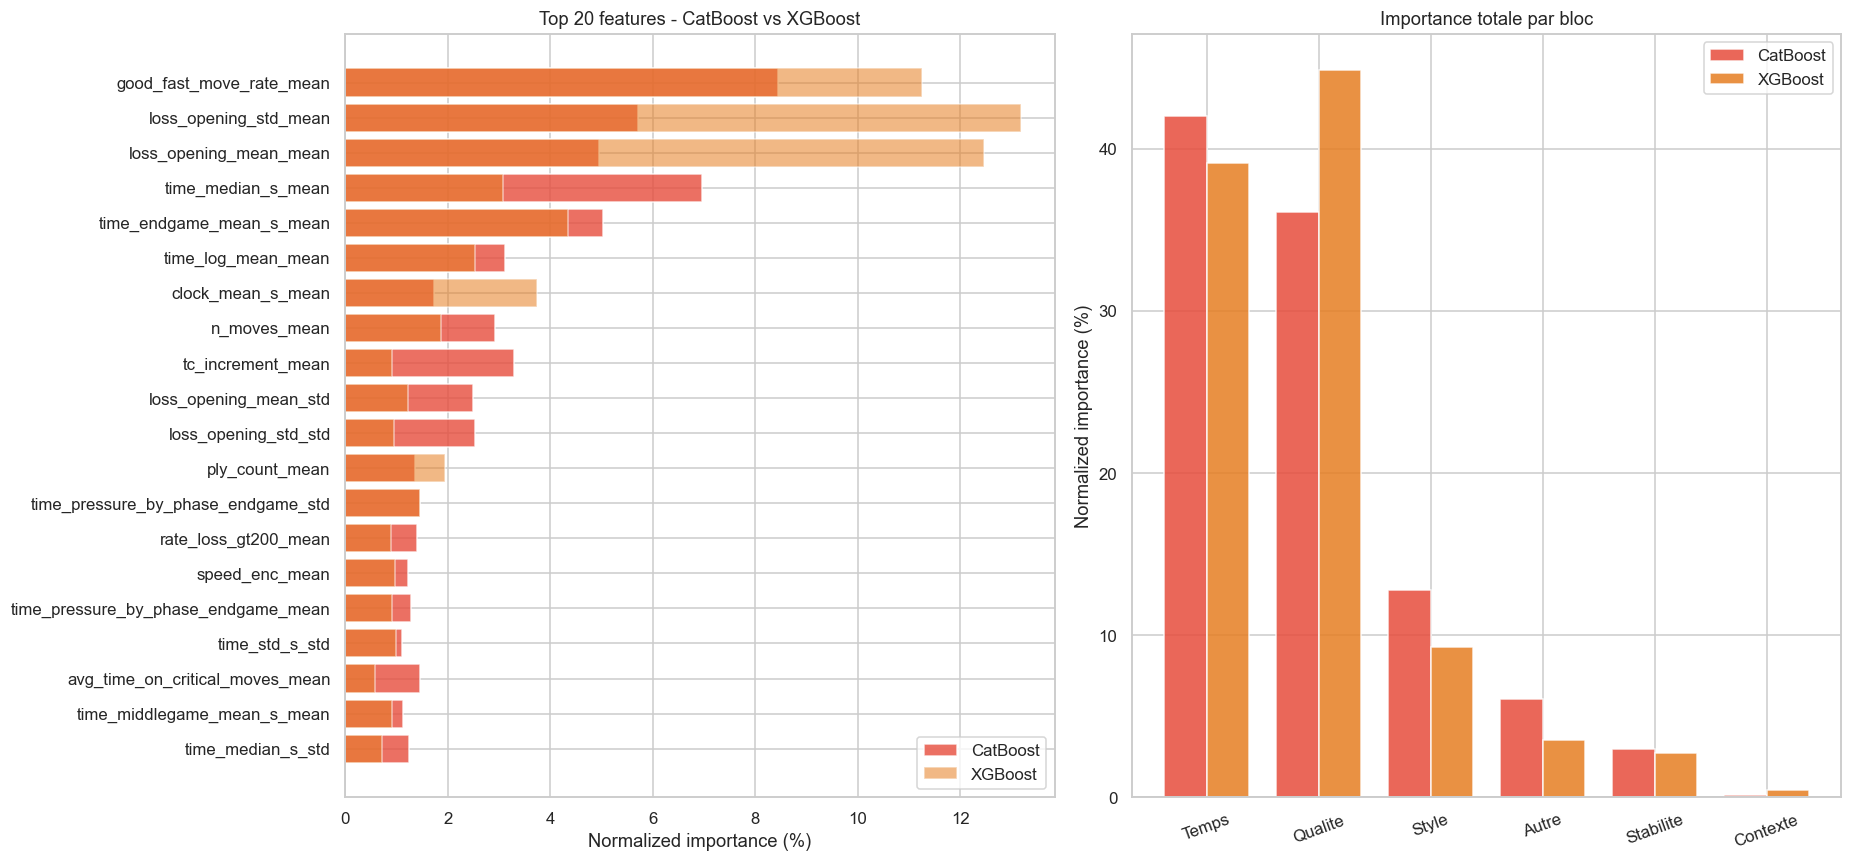

=== Importance par bloc ===
           CatBoost  XGBoost
bloc                        
Temps        42.010   39.130
Qualite      36.090   44.860
Style        12.770    9.280
Autre         6.050    3.540
Stabilite     2.950    2.720
Contexte      0.130    0.480

=== Top 15 features moyennees ===
                                    CatBoost  XGBoost  mean_importance     bloc
good_fast_move_rate_mean               8.446   11.248            9.847    Temps
loss_opening_std_mean                  5.711   13.185            9.448  Qualite
loss_opening_mean_mean                 4.949   12.469            8.709  Qualite
time_median_s_mean                     6.968    3.071            5.020    Temps
time_endgame_mean_s_mean               5.029    4.353            4.691    Temps
time_log_mean_mean                     3.122    2.522            2.822    Temps
clock_mean_s_mean                      1.730    3.734            2.732    Temps
n_moves_mean                           2.914    1.875            

In [21]:
# Feature importance analysis for the two tree models used in stacking
cat_model = base_models['CatBoost'].named_steps['m']
xgb_model = base_models['XGBoost (tuned)'].named_steps['m']

imp_cat = pd.Series(cat_model.feature_importances_, index=feature_cols, name='CatBoost')
imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols, name='XGBoost')

# Normalize for easier comparison
imp_cat = 100 * imp_cat / imp_cat.sum()
imp_xgb = 100 * imp_xgb / imp_xgb.sum()

imp_compare = pd.concat([imp_cat, imp_xgb], axis=1).fillna(0)
imp_compare['mean_importance'] = imp_compare[['CatBoost', 'XGBoost']].mean(axis=1)


def tag_bloc(name):
    if any(k in name for k in ['time', 'clock', 'low_time', 'fast_move', 'pressure']):
        return 'Temps'
    if any(k in name for k in ['loss', 'rate_good', 'rate_error', 'rate_blunder',
                               'rate_mistake', 'rate_inaccuracy', 'n_blunders',
                               'n_mistakes', 'rate_loss']):
        return 'Qualite'
    if any(k in name for k in ['when_', 'opening', 'middlegame', 'endgame',
                               'winning', 'equal', 'losing']):
        return 'Contexte'
    if any(k in name for k in ['variance', 'stability', 'drift', 'gap',
                               'drop', 'cv', 'prop_games']):
        return 'Stabilite'
    if any(k in name for k in ['capture', 'check', 'castle', 'promotion',
                               'eco', 'speed', 'n_moves', 'ply']):
        return 'Style'
    return 'Autre'

imp_compare['bloc'] = imp_compare.index.map(tag_bloc)

top20 = imp_compare.sort_values('mean_importance', ascending=False).head(20).sort_values('mean_importance')
bloc_compare = imp_compare.groupby('bloc')[['CatBoost', 'XGBoost']].sum().sort_values('CatBoost', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Top features by average importance
axes[0].barh(top20.index, top20['CatBoost'], color='#e74c3c', alpha=0.8, label='CatBoost')
axes[0].barh(top20.index, top20['XGBoost'], color='#e67e22', alpha=0.55, label='XGBoost')
axes[0].set_title('Top 20 features - CatBoost vs XGBoost')
axes[0].set_xlabel('Normalized importance (%)')
axes[0].legend()

# Bloc-level comparison
x = np.arange(len(bloc_compare.index))
width = 0.38
axes[1].bar(x - width/2, bloc_compare['CatBoost'], width, color='#e74c3c', alpha=0.85, label='CatBoost')
axes[1].bar(x + width/2, bloc_compare['XGBoost'], width, color='#e67e22', alpha=0.85, label='XGBoost')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bloc_compare.index, rotation=20)
axes[1].set_title('Importance totale par bloc')
axes[1].set_ylabel('Normalized importance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Text summaries
top10_cat = set(imp_compare.sort_values('CatBoost', ascending=False).head(10).index)
top10_xgb = set(imp_compare.sort_values('XGBoost', ascending=False).head(10).index)
overlap = sorted(top10_cat & top10_xgb)

print('=== Importance par bloc ===')
print(bloc_compare.round(2).to_string())

print('\n=== Top 15 features moyennees ===')
print(
    imp_compare.sort_values('mean_importance', ascending=False)
    .head(15)[['CatBoost', 'XGBoost', 'mean_importance', 'bloc']]
    .round(3)
    .to_string()
)

print('\n=== Overlap top 10 CatBoost / XGBoost ===')
print(f'{len(overlap)}/10 features en commun')
for feat in overlap:
    print(f'[{tag_bloc(feat):10s}] {feat}')

imp_compare.sort_values('mean_importance', ascending=False).to_csv(
    'results/tables/feature_importances_stacking_base_1000x100.csv'
)
print('\nSaved feature_importances_stacking_base_1000x100.csv')


## OOF blend and stacking

We build train meta-features with out-of-fold predictions only.
Then we test:
- an OOF-optimized convex blend
- several light meta-models


In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_order = ['CatBoost', 'XGBoost (tuned)', 'Ridge']

oof_train = []
test_pred = []
for name in model_order:
    model = base_models[name]
    oof = cross_val_predict(model, X_train, y_train, cv=cv, method='predict', n_jobs=1)
    oof_train.append(oof)
    model.fit(X_train, y_train)
    test_pred.append(model.predict(X_test))
    print(f'{name:18s} OOF train MAE={mean_absolute_error(y_train, oof):.3f}')

X_meta_train = np.vstack(oof_train).T
X_meta_test = np.vstack(test_pred).T
meta_feature_names = ['pred_catboost', 'pred_xgb', 'pred_ridge']

print('Meta train shape:', X_meta_train.shape)
print('Meta test shape :', X_meta_test.shape)


CatBoost           OOF train MAE=126.666
XGBoost (tuned)    OOF train MAE=124.643
Ridge              OOF train MAE=132.967
Meta train shape: (800, 3)
Meta test shape : (200, 3)


In [23]:
# OOF-optimized convex blend
best_blend = None
for w_cat in np.arange(0, 1.0001, 0.02):
    for w_xgb in np.arange(0, 1.0001, 0.02):
        w_ridge = 1 - w_cat - w_xgb
        if w_ridge < -1e-9 or w_ridge > 1:
            continue
        pred_train = (
            w_cat * X_meta_train[:, 0] +
            w_xgb * X_meta_train[:, 1] +
            w_ridge * X_meta_train[:, 2]
        )
        mae_train = mean_absolute_error(y_train, pred_train)
        if best_blend is None or mae_train < best_blend['train_mae']:
            best_blend = {
                'w_cat': float(w_cat),
                'w_xgb': float(w_xgb),
                'w_ridge': float(w_ridge),
                'train_mae': float(mae_train),
            }

pred_blend = (
    best_blend['w_cat'] * X_meta_test[:, 0] +
    best_blend['w_xgb'] * X_meta_test[:, 1] +
    best_blend['w_ridge'] * X_meta_test[:, 2]
)

blend_row = score_row('OOF blend (Cat/XGB/Ridge)', y_test, pred_blend)
print('Best OOF blend weights:', best_blend)
print(blend_row)
blend_row


Best OOF blend weights: {'w_cat': 0.12, 'w_xgb': 0.52, 'w_ridge': 0.36, 'train_mae': 119.34776041338293}
{'Model': 'OOF blend (Cat/XGB/Ridge)', 'MAE': 102.73970471876274, 'RMSE': np.float64(131.84043572251292), 'R2': 0.8321061178893084}


{'Model': 'OOF blend (Cat/XGB/Ridge)',
 'MAE': 102.73970471876274,
 'RMSE': np.float64(131.84043572251292),
 'R2': 0.8321061178893084}

In [24]:
meta_models = {
    'Stacking - LinearRegression': LinearRegression(),
    'Stacking - Ridge': Ridge(alpha=1.0),
    'Stacking - Huber': Pipeline([
        ('s', StandardScaler()),
        ('m', HuberRegressor()),
    ]),
    'Stacking - ElasticNet': Pipeline([
        ('s', StandardScaler()),
        ('m', ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=10000)),
    ]),
}

stack_rows = []
stack_coefs = {}
stack_test_pred = {}
for name, meta in meta_models.items():
    meta.fit(X_meta_train, y_train)
    pred = meta.predict(X_meta_test)
    stack_test_pred[name] = pred
    row = score_row(name, y_test, pred)
    stack_rows.append(row)
    print(f"{name:28s} MAE={row['MAE']:.3f}  RMSE={row['RMSE']:.3f}  R2={row['R2']:.3f}")

    coef = None
    if hasattr(meta, 'coef_'):
        coef = meta.coef_
    elif hasattr(meta, 'named_steps') and hasattr(meta.named_steps.get('m', None), 'coef_'):
        coef = meta.named_steps['m'].coef_
    if coef is not None:
        stack_coefs[name] = {k: float(v) for k, v in zip(meta_feature_names, coef)}

stack_results_df = pd.DataFrame(stack_rows).sort_values('MAE').reset_index(drop=True)
stack_results_df


Stacking - LinearRegression  MAE=100.140  RMSE=128.818  R2=0.840
Stacking - Ridge             MAE=100.140  RMSE=128.818  R2=0.840
Stacking - Huber             MAE=100.768  RMSE=129.090  R2=0.839
Stacking - ElasticNet        MAE=100.090  RMSE=128.878  R2=0.840


,Model,MAE,RMSE,R2
0,Stacking - ElasticNet,100.090,128.878,0.840
1,Stacking - Ridge,100.140,128.818,0.840
2,Stacking - LinearRegression,100.140,128.818,0.840
3,Stacking - Huber,100.768,129.090,0.839


In [25]:
all_results = pd.concat([
    base_results_df,
    pd.DataFrame([blend_row]),
    stack_results_df,
], ignore_index=True).sort_values('MAE').reset_index(drop=True)

all_test_pred = {}
all_test_pred.update(base_test_pred)
all_test_pred['OOF blend (Cat/XGB/Ridge)'] = pred_blend
all_test_pred.update(stack_test_pred)

print('Final ranking')
print(all_results.to_string(index=False))
all_results


Final ranking
                      Model     MAE    RMSE    R2
      Stacking - ElasticNet 100.090 128.878 0.840
           Stacking - Ridge 100.140 128.818 0.840
Stacking - LinearRegression 100.140 128.818 0.840
           Stacking - Huber 100.768 129.090 0.839
  OOF blend (Cat/XGB/Ridge) 102.740 131.840 0.832
                   CatBoost 109.246 143.262 0.802
            XGBoost (tuned) 112.744 142.680 0.803
                      Ridge 117.443 146.810 0.792


,Model,MAE,RMSE,R2
0,Stacking - ElasticNet,100.090,128.878,0.840
1,Stacking - Ridge,100.140,128.818,0.840
2,Stacking - LinearRegression,100.140,128.818,0.840
3,Stacking - Huber,100.768,129.090,0.839
4,OOF blend (Cat/XGB/Ridge),102.740,131.840,0.832
5,CatBoost,109.246,143.262,0.802
6,XGBoost (tuned),112.744,142.680,0.803
7,Ridge,117.443,146.810,0.792


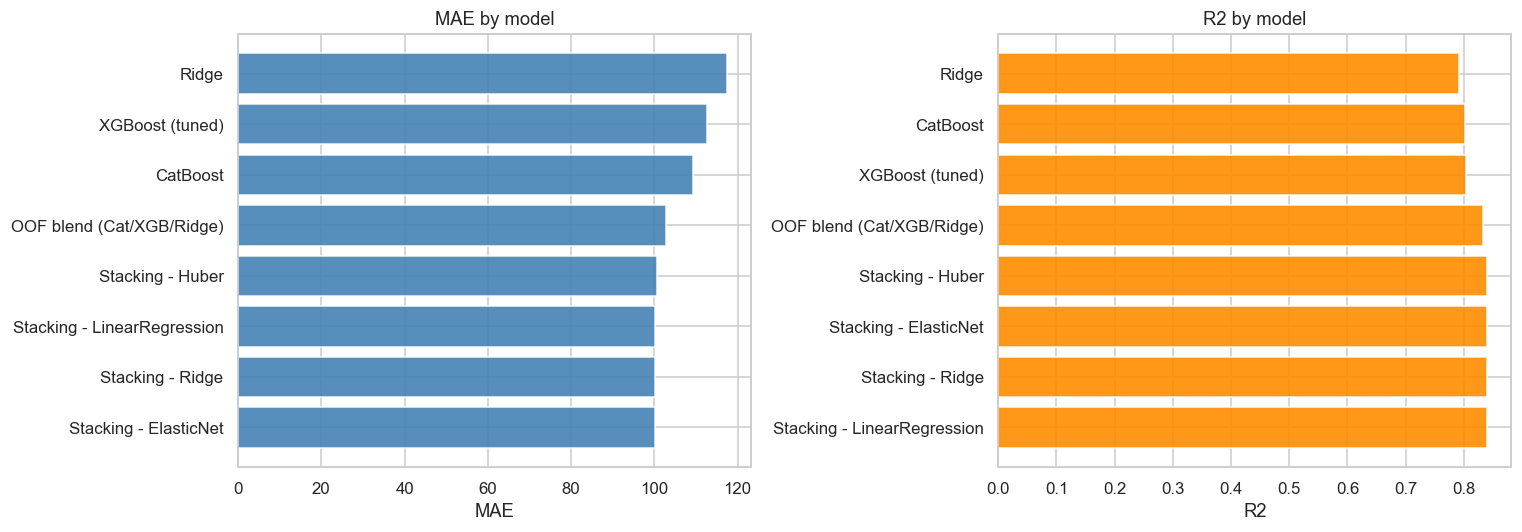

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = all_results.sort_values('MAE', ascending=True)
axes[0].barh(plot_df['Model'], plot_df['MAE'], color='steelblue', alpha=0.9)
axes[0].set_title('MAE by model')
axes[0].set_xlabel('MAE')

plot_df2 = all_results.sort_values('R2', ascending=False)
axes[1].barh(plot_df2['Model'], plot_df2['R2'], color='darkorange', alpha=0.9)
axes[1].set_title('R2 by model')
axes[1].set_xlabel('R2')

plt.tight_layout()
plt.show()


In [27]:
best_model_row = all_results.iloc[0]
print('Best result on this split:')
print(best_model_row.to_string())

print('\nMeta-model coefficients (when available):')
for name, coef_map in stack_coefs.items():
    print(name)
    print(coef_map)


Best result on this split:
Model    Stacking - ElasticNet
MAE                    100.090
RMSE                   128.878
R2                       0.840

Meta-model coefficients (when available):
Stacking - LinearRegression
{'pred_catboost': 0.25923943497487223, 'pred_xgb': 0.42656249712155836, 'pred_ridge': 0.38641921261101025}
Stacking - Ridge
{'pred_catboost': 0.25923952313349957, 'pred_xgb': 0.42656241108501064, 'pred_ridge': 0.3864192052641677}
Stacking - Huber
{'pred_catboost': 53.49789681198953, 'pred_xgb': 129.86788881923852, 'pred_ridge': 97.04372683793605}
Stacking - ElasticNet
{'pred_catboost': 72.98050874932918, 'pred_xgb': 103.51020637880978, 'pred_ridge': 101.20563200254854}


• ## 7. Évaluation Visuelle

  On visualise le meilleur modèle retenu sur ce split avec :
  - nuage `Elo réel` vs `Elo prédit`
  - histogramme des résidus
  - résidus en fonction des prédictions

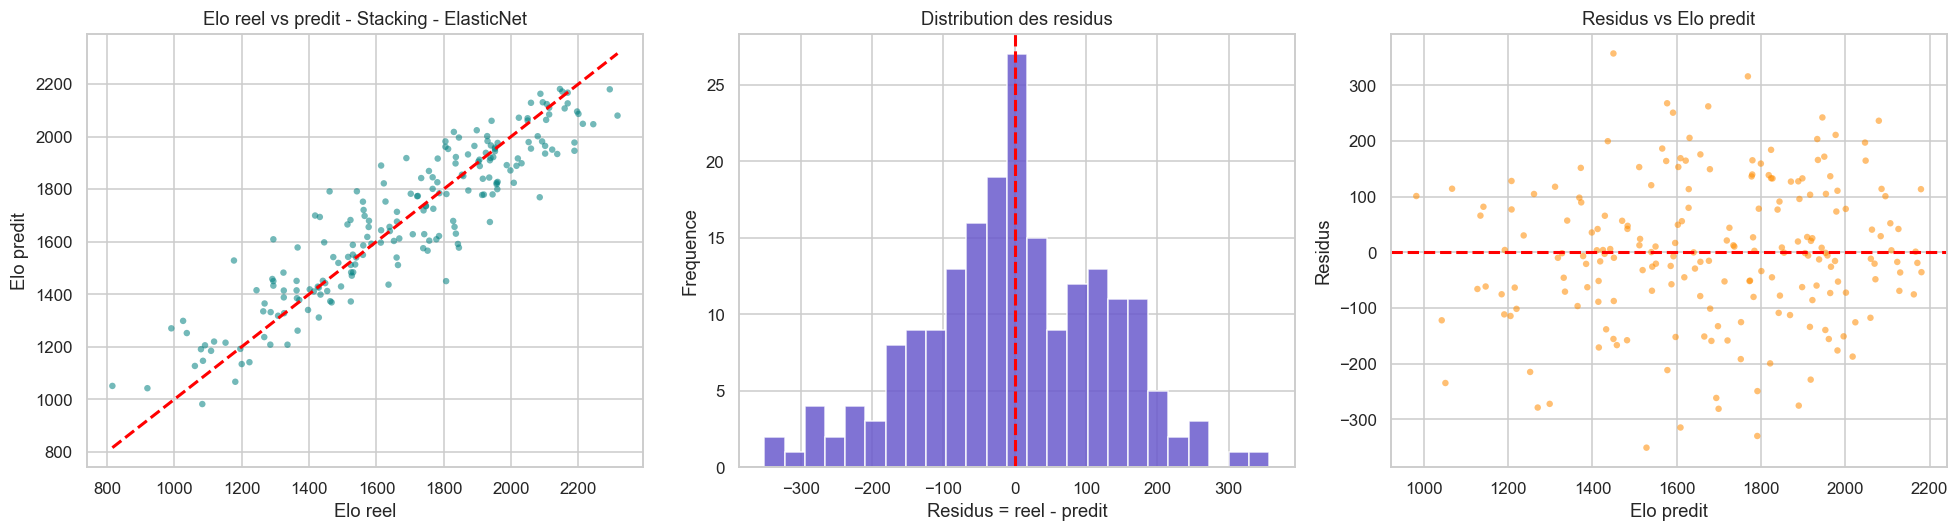

Best visualized model: Stacking - ElasticNet
MAE  = 100.09
RMSE = 128.878
R2   = 0.84


In [28]:
best_model_name = all_results.iloc[0]['Model']
best_pred = all_test_pred[best_model_name]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real vs predicted
min_elo = min(y_test.min(), best_pred.min())
max_elo = max(y_test.max(), best_pred.max())
axes[0].scatter(y_test, best_pred, s=18, alpha=0.55, color='teal', edgecolors='none')
axes[0].plot([min_elo, max_elo], [min_elo, max_elo], '--', color='red', linewidth=2)
axes[0].set_title(f'Elo reel vs predit - {best_model_name}')
axes[0].set_xlabel('Elo reel')
axes[0].set_ylabel('Elo predit')

# Residual histogram
axes[1].hist(residuals, bins=25, color='slateblue', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution des residus')
axes[1].set_xlabel('Residus = reel - predit')
axes[1].set_ylabel('Frequence')

# Residuals vs predicted
axes[2].scatter(best_pred, residuals, s=18, alpha=0.55, color='darkorange', edgecolors='none')
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Residus vs Elo predit')
axes[2].set_xlabel('Elo predit')
axes[2].set_ylabel('Residus')

plt.tight_layout()
plt.show()

print('Best visualized model:', best_model_name)
print('MAE  =', round(mean_absolute_error(y_test, best_pred), 3))
print('RMSE =', round(np.sqrt(mean_squared_error(y_test, best_pred)), 3))
print('R2   =', round(r2_score(y_test, best_pred), 3))


In [29]:
import json
from pathlib import Path

all_results.to_csv('results/tables/results_stacking_from_csv_1000x100.csv', index=False)
print('Saved results_stacking_from_csv_1000x100.csv')

Path('results/configs/stacking_blend_weights_1000x100.json').write_text(
    json.dumps(best_blend, indent=2),
    encoding='utf-8'
)
print('Saved stacking_blend_weights_1000x100.json')

Path('results/configs/stacking_meta_coeffs_1000x100.json').write_text(
    json.dumps(stack_coefs, indent=2),
    encoding='utf-8'
)
print('Saved stacking_meta_coeffs_1000x100.json')


Saved results_stacking_from_csv_1000x100.csv
Saved stacking_blend_weights_1000x100.json
Saved stacking_meta_coeffs_1000x100.json
